In [1]:
from sklearn.neighbors  import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

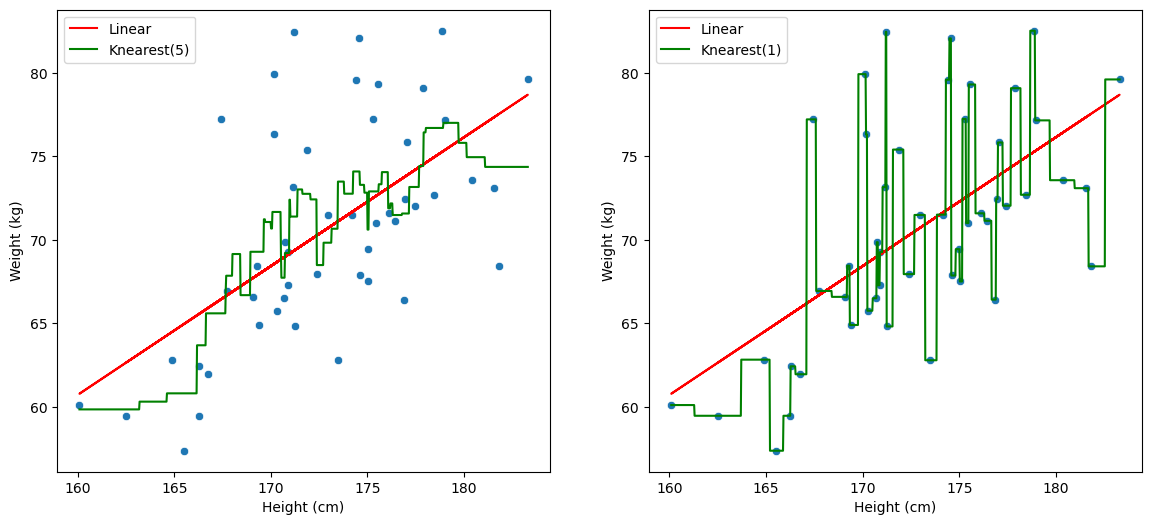

In [2]:
model_1 = KNeighborsRegressor( n_neighbors=1, 
                             p = 2 ,
                             weights= 'uniform' )
model_2 = LinearRegression()

data= np.random.multivariate_normal( [ 173, 70 ] ,
                                     [ [ 25, 20 ],
                                       [20, 36 ] ],
                                     size = (50,) 
                                   )
X,y = data[:,0].reshape(-1,1) , data[:,1].reshape(-1,1)
model_2.fit(X,y)
model_1.fit(X,y)
y_pred_2=model_2.predict(X)

X_line = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
y_pred_1 = model_1.predict(X_line)


fig , ax = plt.subplots(1,2, figsize =(14,6))
sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[1])
ax[1].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[1].plot( X_line, y_pred_1, color ='green' , label ='Knearest(1)' ) 
ax[1].legend()
ax[1].set_xlabel('Height (cm)')
ax[1].set_ylabel('Weight (kg)')



model_1 = KNeighborsRegressor( n_neighbors=5, 
                             p = 2 ,
                             weights= 'uniform' )
model_1.fit(X,y)
y_pred_1 = model_1.predict(X_line)

sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[0])
ax[0].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[0].plot( X_line, y_pred_1, color ='green' , label ='Knearest(5)' ) 
ax[0].legend()
ax[0].set_xlabel('Height (cm)')
ax[0].set_ylabel('Weight (kg)')


plt.show()

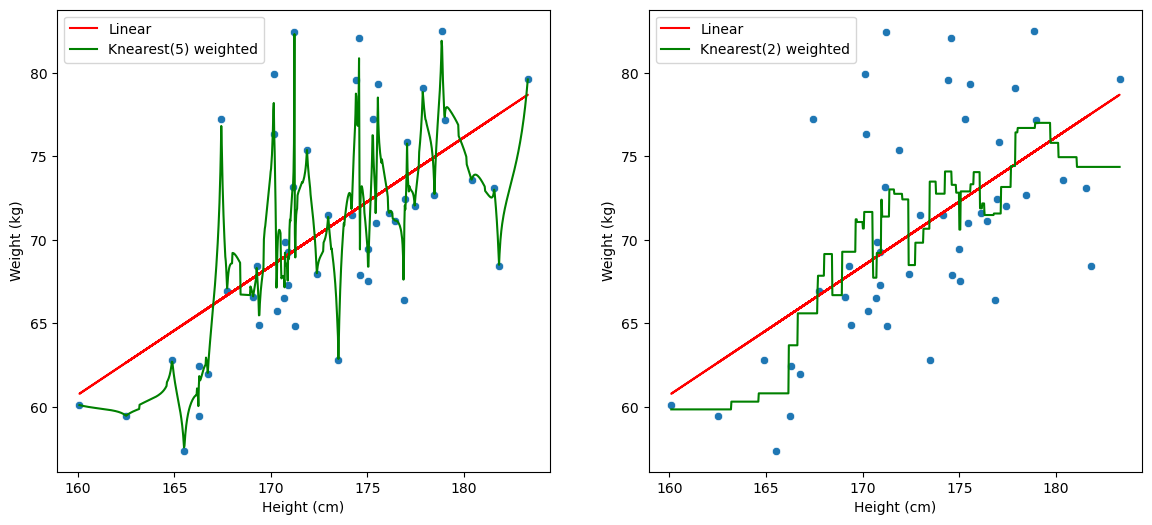

In [3]:
model_1 = KNeighborsRegressor( n_neighbors=2, 
                             p = 2 ,
                             weights= 'distance' )

fig , ax = plt.subplots(1,2, figsize =(14,6))
sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[1])
ax[1].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[1].plot( X_line, y_pred_1, color ='green' , label ='Knearest(2) weighted' ) 
ax[1].legend()
ax[1].set_xlabel('Height (cm)')
ax[1].set_ylabel('Weight (kg)')



model_1 = KNeighborsRegressor( n_neighbors=5, 
                             p = 2 ,
                             weights= 'distance' )
model_1.fit(X,y)
y_pred_1 = model_1.predict(X_line)

sns.scatterplot (  x= data[:,0] , y= data[:,1] , ax = ax[0])
ax[0].plot( X, y_pred_2, color ='red' , label ='Linear' )
ax[0].plot( X_line, y_pred_1, color ='green' , label ='Knearest(5) weighted' ) 
ax[0].legend()
ax[0].set_xlabel('Height (cm)')
ax[0].set_ylabel('Weight (kg)')


plt.show()

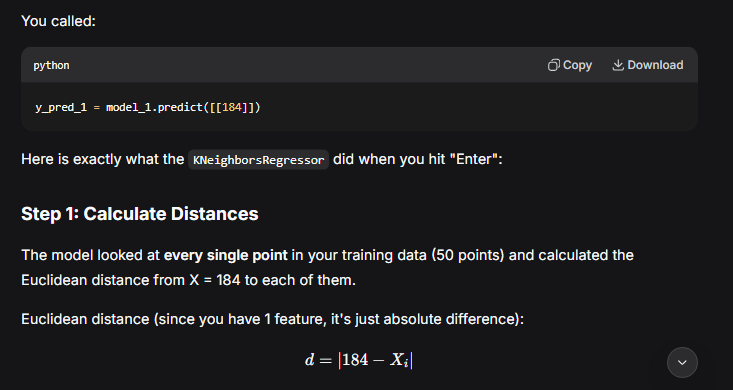

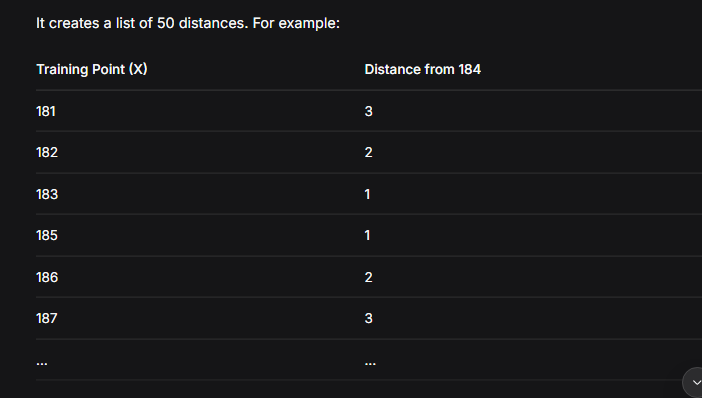

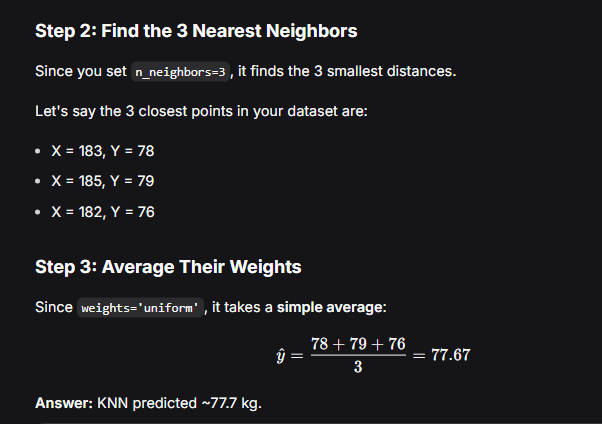

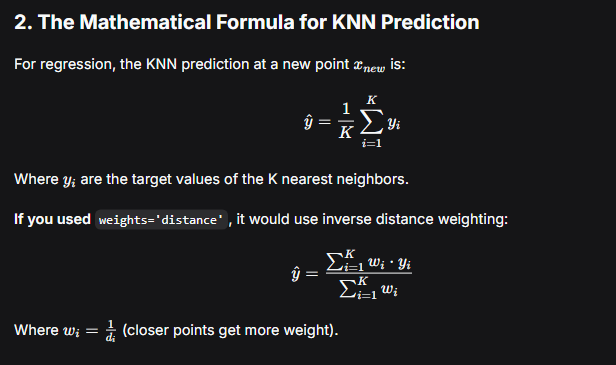

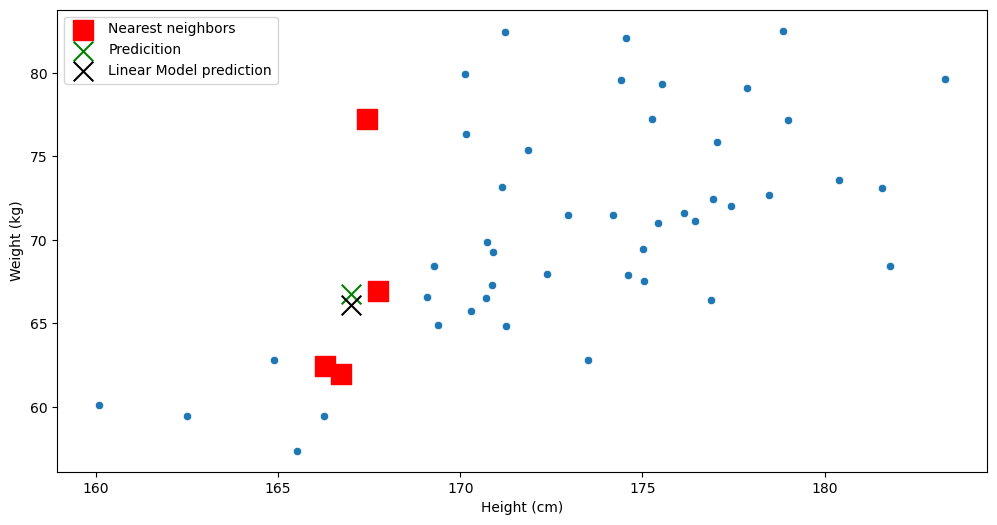

In [4]:
model_1 = KNeighborsRegressor( n_neighbors=4, 
                             p = 2 ,
                             weights= 'distance' )
model_1.fit(X,y)
distances, indices = model_1.kneighbors([[167]])

plt.figure( figsize = (12,6))
sns.scatterplot (  x= data[:,0] , y= data[:,1] )
plt.scatter( X[indices][0] , y[indices][0], color = 'red' , label ='Nearest neighbors' , s = 200, marker = 's' )
plt.scatter ( [167] , model_1.predict([[167]]) , color = 'green' , label = 'Predicition' , s= 200, marker = 'x')
plt.scatter ( [167] , model_2.predict([[167]]) , color = 'black' , label = 'Linear Model prediction' , s= 200, marker = 'x')
plt.legend()
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

In [5]:
model_2.coef_  , model_2.intercept_#A unit increase in height adds 0.8kg

(array([[0.77086644]]), array([-62.61431168]))

In [6]:
scale = StandardScaler()
X_t = scale.fit_transform(X)
model_2.fit(X_t, y ) 
model_2.coef_ , model_2.intercept_

(array([[3.86032603]]), array([70.56839831]))

This is scaled coeffecients whichs means 1 standard deviation of height adds 5.12 kg

and the intercept means the when height = height mean the intercept term not when hieght = 0 which means 71kg is weight when mean hieght

In [7]:
model_2.coef_ /scale.scale_[0]  #same scaling as above

array([[0.77086644]])

In [8]:

model_2.intercept_[0] - (model_2.coef_[0][0] * scale.mean_[0] / scale.scale_[0])


np.float64(-62.61431167546458)

The same thing applies for the logistic regression coeffecients in the previous notebooks

In [19]:
model_1 = KNeighborsRegressor( n_neighbors=5, 
                             p = 2 ,
                             weights= 'uniform' )
model_2 = LinearRegression()

data= np.random.multivariate_normal( [ 173, 70 ] ,
                                     [ [ 25, 20 ],
                                       [20, 36 ] ],
                                     size = (50,) 
                                   )
X,y = data[:,0].reshape(-1,1) , data[:,1].reshape(-1,1)
model_2.fit(X,y)
model_1.fit(X,y)

r2_score(y , model_1.predict(X)) , r2_score(y, model_2.predict(X)) 

(0.520183200584379, 0.3293816290688105)

If the data is non-linear knn works well good (low dimension) , if the data is linear linear regression is better

Linear regression with non linear data with high dimension can work better with polynomial features and the regularization

In [20]:
root_mean_squared_error(y , model_1.predict(X)) , root_mean_squared_error(y, model_2.predict(X)) 

(3.589309665610532, 4.243370246405894)